# Spoken Wiki attentional word recognition pilot task results

In [88]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



### Import human data

In [89]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_word_recognition_short*/data/*.json"))

# import vocab dict for matching audio & responses 
# word_and_speaker_encodings = pickle.load( open("/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
# # ix_to_word_map = {v:k for k,v in class_map.items()}
# class_map = word_and_speaker_encodings['word_idx_to_word']
len(human_fnames)

54

In [90]:
## Get all subject data into one df for analysis

def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    # print(f"{fname.stem} success {part_data[0]['success']}")
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df

dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]


## Add snr and condition names as columns - unpack from file code in file names 

import re
# get cond name map
map_path = Path('/om2/user/imgriff/projects/Auditory-Attention/human_saddler_attn_expmt_cond_map.pkl')
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)

stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}

## Map wav str to stim_type using condition dict
def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    condition, snr = None,  None 
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        # print(stim_str)
        cond_str = re.search("condition_(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            condition, snr = stim_cond_map[cond_str]
        elif 'catch' in stim_str:
            condition = 'catch_trial'
            snr = np.inf
    return snr, condition

# add as columns 
results_df['snr'], results_df['condition'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))

# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str]

# Convert condition names to  readable format 
test_condition_dict = {'music':"background_musdb18hq",
                       "babble":"background_cv08talkerbabble",
                       "stationary": "background_issnstationary",
                       "modulated": "background_issnfestenplomp",
                       "audioset": "background_audioset",
                       "natural scene": "background_ieeeaaspcasa",
                       "clean": "SILENCE"}

condition_map = {v:k for k,v in test_condition_dict.items()}
trial_results['condition'] = trial_results['condition'].replace(condition_map)


# screen based on completion 
total_trials = 192 
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').condition.count() == total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]

# Add accuracy 
trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')


Unterminated string starting at: line 1 column 84036 (char 84035)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_6393f158851fb438d2ceb5d7.json
Unterminated string starting at: line 1 column 300457 (char 300456)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_631ffc3584141f143567f021.json
Unterminated string starting at: line 1 column 168069 (char 168068)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_5978f6f009bdcf000153f43d.json
Unterminated string starting at: line 1 column 71988 (char 71987)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_631610af8e747093cd90e00d.json
Unterminated string starting at: line 1 column 192239 (char 192238)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_57165ba7c5aca2000a8d32ca.json


/tmp/ipykernel_4100545/438142362.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_results['condition'] = trial_results['condition'].replace(condition_map)
/tmp/ipykernel_4100545/438142362.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')


In [91]:
trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()
catch_trial_particiapnt_performance

/tmp/ipykernel_4100545/798094779.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')


id_subject
56f81ffe1b99b8000636b9c8    1.000000
5a048293517dfb00013db3a7    1.000000
5bfd651ab098c7000144c66b    0.750000
5ced0da70afd6e0001a9f211    1.000000
5e3da76a9e51f801298c7510    0.916667
5f105271a8af7c163ce00e14    1.000000
6021c4832fdecb24a70f4746    1.000000
60471cafee39c41a2b92815f    0.750000
60abbb05288f7eeb1312c3b7    1.000000
60f4696161736ffaef73b434    1.000000
6120ac8c17e365d3bdbb6272    1.000000
62fbc49ef8c2c8ce7ed12530    0.833333
634d0838a4cc661c5034327d    0.916667
637e7c56b8a297cfd18ff2ac    0.916667
63b80a8b220f924d975670bc    0.916667
63d02671ad31b646d65d2498    0.833333
63d076d846d3d9dc35910778    1.000000
63d1a365d7af03c9452d432c    0.916667
65269c98d6fe44c6fc33119b    0.916667
65410d5bb6f25eb9988b5c4b    1.000000
Name: accuracy, dtype: float64

In [227]:
print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 10/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]

N total participants  20
N good participants  18


In [228]:
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response_str.isna())]
analysis_df.groupby('id_subject').condition.count()

id_subject
56f81ffe1b99b8000636b9c8    192
5a048293517dfb00013db3a7    192
5ced0da70afd6e0001a9f211    192
5e3da76a9e51f801298c7510    192
5f105271a8af7c163ce00e14    192
6021c4832fdecb24a70f4746    192
60abbb05288f7eeb1312c3b7    192
60f4696161736ffaef73b434    192
6120ac8c17e365d3bdbb6272    192
62fbc49ef8c2c8ce7ed12530    192
634d0838a4cc661c5034327d    192
637e7c56b8a297cfd18ff2ac    192
63b80a8b220f924d975670bc    192
63d02671ad31b646d65d2498    192
63d076d846d3d9dc35910778    192
63d1a365d7af03c9452d432c    192
65269c98d6fe44c6fc33119b    192
65410d5bb6f25eb9988b5c4b    192
Name: condition, dtype: int64

In [229]:
# get trial data excluding catch trials 
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response_str.isna())]


part_summary_df = (analysis_df.groupby(["snr", 'id_subject', "condition"])
                     .correct
                     .agg(["mean"])
                     .reset_index())

part_summary_df['snr'] = part_summary_df['snr'].replace(np.inf, 6)
part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)
part_summary_df['snr'] = part_summary_df['snr'].astype('int')


In [230]:
part_summary_df.id_subject.value_counts() # should be 37 (36 experimental conditions + catch trial)

56f81ffe1b99b8000636b9c8    37
5a048293517dfb00013db3a7    37
65269c98d6fe44c6fc33119b    37
63d1a365d7af03c9452d432c    37
63d076d846d3d9dc35910778    37
63d02671ad31b646d65d2498    37
63b80a8b220f924d975670bc    37
637e7c56b8a297cfd18ff2ac    37
634d0838a4cc661c5034327d    37
62fbc49ef8c2c8ce7ed12530    37
6120ac8c17e365d3bdbb6272    37
60f4696161736ffaef73b434    37
60abbb05288f7eeb1312c3b7    37
6021c4832fdecb24a70f4746    37
5f105271a8af7c163ce00e14    37
5e3da76a9e51f801298c7510    37
5ced0da70afd6e0001a9f211    37
65410d5bb6f25eb9988b5c4b    37
Name: id_subject, dtype: int64

In [231]:
summary_df = part_summary_df.groupby(['snr', 'condition']).agg({'mean': ['mean', 'sem', 'count']}).reset_index()
summary_df.columns = ['snr', 'background_condition', 'accuracy', 'std_error', 'N']


In [232]:
part_summary_df

,snr,id_subject,condition,mean
0,-9,56f81ffe1b99b8000636b9c8,1-talker,0.8
1,-9,56f81ffe1b99b8000636b9c8,4-talker,0.0
2,-9,56f81ffe1b99b8000636b9c8,babble,0.0
3,-9,56f81ffe1b99b8000636b9c8,modulated,0.4
4,-9,56f81ffe1b99b8000636b9c8,music,0.2
...,...,...,...,...
661,6,63d02671ad31b646d65d2498,clean,0.2
662,6,63d076d846d3d9dc35910778,clean,0.6
663,6,63d1a365d7af03c9452d432c,clean,1.0
664,6,65269c98d6fe44c6fc33119b,clean,0.6


In [233]:
summary_df

,snr,background_condition,accuracy,std_error,N
0,-9,1-talker,0.277778,0.056334,18
1,-9,4-talker,0.100000,0.033333,18
2,-9,babble,0.033333,0.018078,18
3,-9,modulated,0.322222,0.046128,18
4,-9,music,0.433333,0.043536,18
5,-9,natural scene,0.255556,0.038959,18
6,-9,stationary,0.088889,0.033224,18
7,-6,1-talker,0.388889,0.057103,18
8,-6,4-talker,0.100000,0.033333,18
9,-6,babble,0.100000,0.029149,18


(0.0, 1.0)

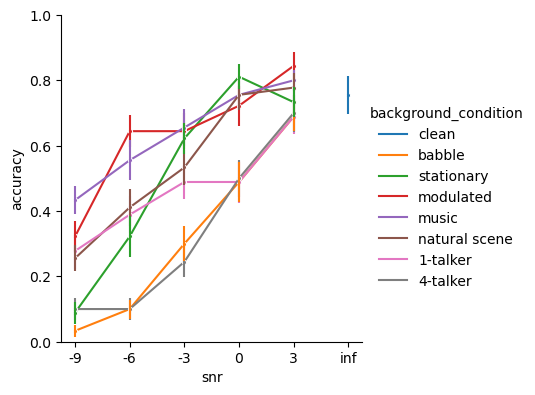

In [234]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = summary_df[~summary_df.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['clean', 'babble',  'stationary', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

# Make color map 

# add markers to relplot
# plt.figure(figsize=(2,2))
g = sns.relplot(data=to_plot, x='snr', y='accuracy', hue='background_condition', hue_order=hue_order,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', marker='.', palette=palette, height=4, aspect=1)
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')


# iterate through each facet of the facetgrid
# for model, ax in g.axes_dict.items():
    # select the data for the facet
    # data = to_plot[to_plot['model'].eq(model)]

    # select the data for each hue group
for group, selected in to_plot.groupby('background_condition'):
    # plot the errorbar with the correct color for each group 
    # print(group)
    g.axes[0,0].errorbar(data=selected, x="snr", y="accuracy", yerr="std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)

# plt.tight_layout()

babble
clean
modulated
music
natural scene
stationary


(0.0, 1.0)

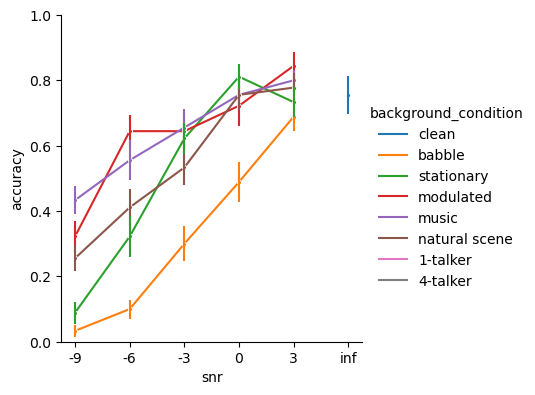

In [235]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = summary_df[~summary_df.background_condition.isin(["catch_trial", "1-talker", "4-talker", "audioset"])]
# palette = dict(zip(to_plot.background_condition.unique(), sns.color_palette(n_colors= len(to_plot.background_condition.unique()), as_cmap=True)))

# add markers to relplot
# plt.figure(figsize=(2,2))
g = sns.relplot(data=to_plot, x='snr', y='accuracy', hue='background_condition', hue_order=hue_order,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', marker='.', palette=palette, height=4, aspect=1)
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')


# iterate through each facet of the facetgrid
# for model, ax in g.axes_dict.items():
    # select the data for the facet
    # data = to_plot[to_plot['model'].eq(model)]

    # select the data for each hue group
for group, selected in to_plot.groupby('background_condition'):
    # plot the errorbar with the correct color for each group 
    print(group)
    g.axes[0,0].errorbar(data=selected, x="snr", y="accuracy", yerr="std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)



# plt.tight_layout()

In [236]:
part_summary_df.rename(columns={'mean': 'accuracy', 'condition': "background_condition"}, inplace=True)

In [237]:
part_summary_df

,snr,id_subject,background_condition,accuracy
0,-9,56f81ffe1b99b8000636b9c8,1-talker,0.8
1,-9,56f81ffe1b99b8000636b9c8,4-talker,0.0
2,-9,56f81ffe1b99b8000636b9c8,babble,0.0
3,-9,56f81ffe1b99b8000636b9c8,modulated,0.4
4,-9,56f81ffe1b99b8000636b9c8,music,0.2
...,...,...,...,...
661,6,63d02671ad31b646d65d2498,clean,0.2
662,6,63d076d846d3d9dc35910778,clean,0.6
663,6,63d1a365d7af03c9452d432c,clean,1.0
664,6,65269c98d6fe44c6fc33119b,clean,0.6


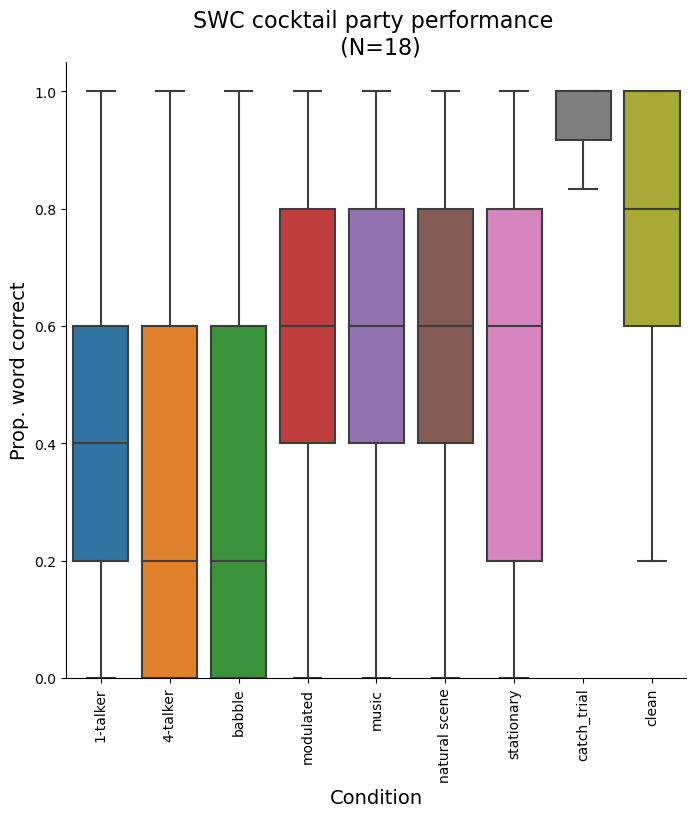

In [238]:
fontsize=14
n_participants = part_summary_df.id_subject.nunique()
fig, axs = plt.subplots(1, figsize=(8,8))

conds = part_summary_df.background_condition.unique()# order = ['clean', 'stationary_noise', 'natural_scene']
p = sns.boxplot( data=part_summary_df, x="background_condition",
                   y="accuracy",  #error='sem',
                   order=conds,
                  #capsize=0.1,
                   ax=axs)

sns.despine()
plt.ylim(0,1.05)
p.set_title(f"SWC cocktail party performance \n (N={n_participants})",
                 fontsize=fontsize + 2)
p.set_xlabel("Condition",fontsize=fontsize)
p.set_ylabel("Prop. word correct", fontsize=fontsize)

p.set_xticklabels(labels=conds, rotation=90, size=10);



In [239]:
part_summary_df.snr.unique()

array([-9, -6, -3,  0,  3,  6])

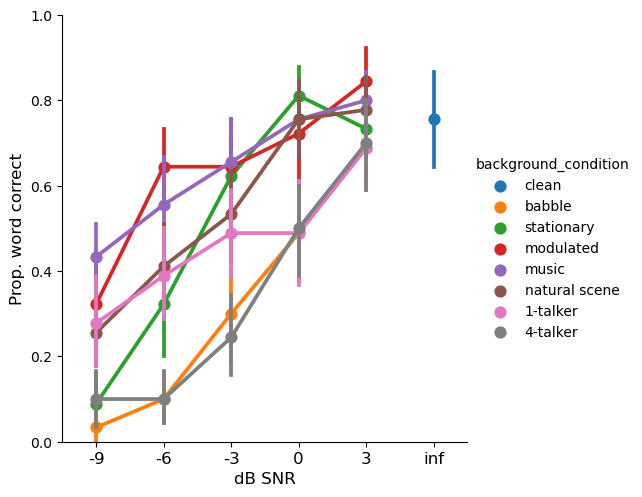

In [240]:
fontsize=12


n_participants = part_summary_df.id_subject.nunique()
# fig, axs = plt.subplots(1, figsize=(8,8))

to_plot = part_summary_df[~part_summary_df.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['clean', 'babble',  'stationary', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

p = sns.catplot( kind='point',data=to_plot, x="snr", error = 'sem',
                   y="accuracy",  hue='background_condition', hue_order=hue_order, 
                #    linestyles="None",
                   palette=palette,
                   )

sns.despine()
plt.ylim(0,1)
# axs.set_title(f"Word Speaker Noise word recognition participant performance \n (N={n_participants})",
#                  fontsize=fontsize + 2)
p.ax.set_xlabel("dB SNR",fontsize=fontsize)
p.ax.set_ylabel("Prop. word correct", fontsize=fontsize)


x_tick_labels = [str(x) for x in part_summary_df.snr.unique()]
x_tick_labels[-1] = 'inf'

# for ax in p.axes.flat:
#     ax.set_xticklabels(labels=x_tick_labels)
p.set_xticklabels(labels=x_tick_labels, rotation=0, size=fontsize)



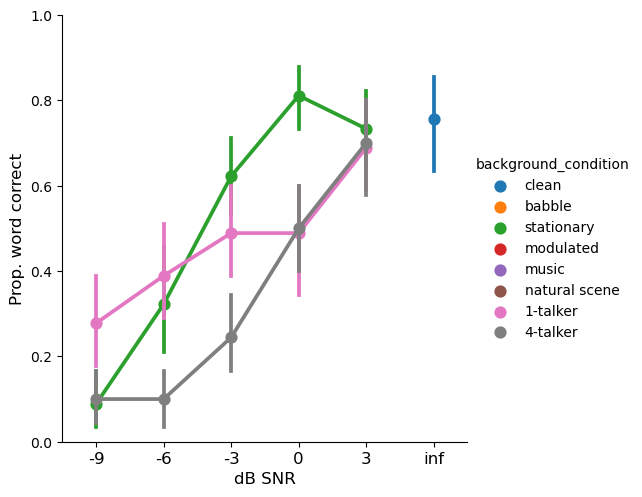

In [241]:
fontsize=12


n_participants = part_summary_df.id_subject.nunique()
# fig, axs = plt.subplots(1, figsize=(8,8))

to_plot = part_summary_df[part_summary_df.background_condition.isin(["clean", '1-talker', '4-talker', 'stationary'])]
p = sns.catplot( kind='point',data=to_plot, x="snr",
                   y="accuracy",  hue='background_condition', hue_order=hue_order, error='sem', 
                #    linestyles="None",
                   palette=palette,
                   )

sns.despine()
plt.ylim(0,1)
# axs.set_title(f"Word Speaker Noise word recognition participant performance \n (N={n_participants})",
#                  fontsize=fontsize + 2)
p.ax.set_xlabel("dB SNR",fontsize=fontsize)
p.ax.set_ylabel("Prop. word correct", fontsize=fontsize)

x_tick_labels = [str(x) for x in part_summary_df.snr.unique()]
x_tick_labels[-1] = 'inf'

# for ax in p.axes.flat:
#     ax.set_xticklabels(labels=x_tick_labels)
p.set_xticklabels(labels=x_tick_labels, rotation=0, size=fontsize)



In [242]:
### Look at 1 talker sex conditions

parent_dir = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2023/sounds/")
wanted_conditions = [cond_dir for cond_dir, cond_tuple in stim_cond_map.items() if cond_tuple[0] == '1-talker']
manifests = pd.concat([pd.read_pickle(parent_dir / cond_dir / 'manifest.pdpkl') for cond_dir in wanted_conditions])
manifests.head()

,target_sr,experiment_key_target_word_ix,cue_sr,target_fn,cue_fn,word,word_int,condition,snr,src_ix,client_id,target_gender,target_f0,distractor_fn,distractor_f0,distractor_gender,distractor_word,mixture_fn
0,44100,0,44100,/om/user/imgriff/datasets/spatial_audio_pipeli...,/om/user/imgriff/datasets/spatial_audio_pipeli...,above,1,1-talker,-9,310886,mangst,male,109.965641,/om/user/imgriff/datasets/spatial_audio_pipeli...,125.085843,male,countries,/om/user/imgriff/datasets/human_word_rec_SWC_2...
1,44100,1,44100,/om/user/imgriff/datasets/spatial_audio_pipeli...,/om/user/imgriff/datasets/spatial_audio_pipeli...,according,3,1-talker,-9,181635,the-voice-of-hassocks,male,117.046969,/om/user/imgriff/datasets/spatial_audio_pipeli...,135.868215,male,studio,/om/user/imgriff/datasets/human_word_rec_SWC_2...
2,44100,2,44100,/om/user/imgriff/datasets/spatial_audio_pipeli...,/om/user/imgriff/datasets/spatial_audio_pipeli...,across,4,1-talker,-9,310319,mangst,male,112.441986,/om/user/imgriff/datasets/spatial_audio_pipeli...,120.255924,male,married,/om/user/imgriff/datasets/human_word_rec_SWC_2...
3,44100,3,44100,/om/user/imgriff/datasets/spatial_audio_pipeli...,/om/user/imgriff/datasets/spatial_audio_pipeli...,action,5,1-talker,-9,937425,preslethe,male,114.925214,/om/user/imgriff/datasets/spatial_audio_pipeli...,183.153323,male,military,/om/user/imgriff/datasets/human_word_rec_SWC_2...
4,44100,4,44100,/om/user/imgriff/datasets/spatial_audio_pipeli...,/om/user/imgriff/datasets/spatial_audio_pipeli...,activities,7,1-talker,-9,940458,vaslittlecrow,female,207.809580,/om/user/imgriff/datasets/spatial_audio_pipeli...,125.965637,male,worked,/om/user/imgriff/datasets/human_word_rec_SWC_2...


In [243]:
manifests["base_str"] = manifests.mixture_fn.apply(lambda x: f"stim/{x.as_posix().split('sounds/')[1]}") 

In [244]:
trial_results.columns

Index(['success', 'timeout', 'failed_images', 'failed_audio', 'failed_video',
       'trial_type', 'trial_index', 'time_elapsed', 'internal_node_id',
       'output_filename', 'id_random', 'id_study', 'id_subject', 'id_session',
       'id_version', 'hc_passed', 'view_history', 'rt', 'response',
       'question_order', 'stimulus', 'stim_type', 'hc_answer', 'hc_correct',
       'response_str', 'catch_trial', 'correct_response', 'trial_num',
       'correct', 'n_correct', 'n_incorrect', 'snr', 'condition', 'accuracy'],
      dtype='object')

In [245]:
## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifests to trial_results where trial_results.stimulus == manifests.base_str
f0_analysis_df = pd.merge(trial_results, 
                                    manifests[['base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word']],
                                    left_on='stimulus', right_on='base_str', how='left')

f0_analysis_df = f0_analysis_df[f0_analysis_df.condition.isin([ "1-talker", 'clean'])]

f0_analysis_df['gender_cond'] = f0_analysis_df.apply(lambda row: 'same' if row['target_gender'] == row['distractor_gender'] else 'different', axis=1)
f0_analysis_df["f0_diff"] = np.abs(f0_analysis_df.target_f0 - f0_analysis_df.distractor_f0)
f0_analysis_df['confusions'] = (f0_analysis_df.response_str == f0_analysis_df.distractor_word).astype('int')

In [246]:
# Filter as before 
f0_analysis_df = f0_analysis_df[f0_analysis_df.id_subject.isin(good_participants)]

In [247]:
f0_analysis_df.id_subject.nunique()

18

In [248]:
# f0_analysis_df['accuracy'].replace({0: "Incorrect", 1:"Correct"}, inplace=True)

In [249]:
f0_analysis_df['correct_str'] = f0_analysis_df['accuracy'].replace({0: "Miss", 1:"Hit"})

Text(0.5, 0, 'dB SNR')

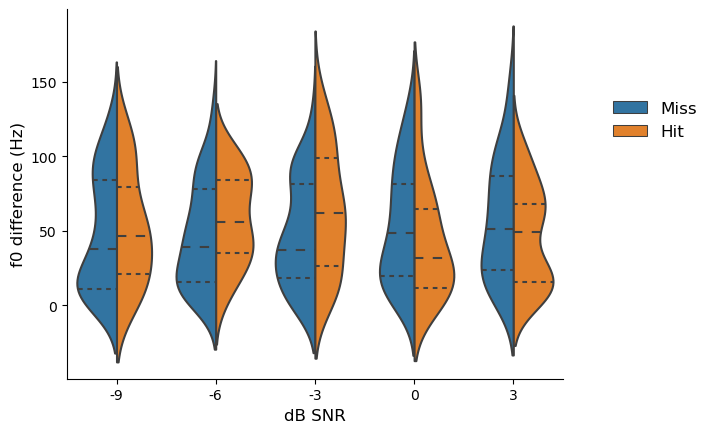

In [250]:
# g = sns.relplot(data=f0_analysis_df, x='f0_diff', y='snr', hue='accuracy',  kind='scatter')
# sns.violinplot(data=f0_analysis_df, x="snr", y="f0_diff", hue="accuracy", split=True, gap=.5, inner="quart")

ax = sns.violinplot(data=f0_analysis_df[f0_analysis_df.condition == '1-talker'], x="snr", y="f0_diff", hue="correct_str", split=True, gap=.5, inner="quart")


sns.move_legend(ax, title='',
                loc="center right", bbox_to_anchor=(1.3, .7),
                frameon=False, title_size=fontsize, fontsize=fontsize)
sns.despine()
ax.set_ylabel('f0 difference (Hz)', fontsize=fontsize)
ax.set_xlabel('dB SNR', fontsize=fontsize)

/tmp/ipykernel_4100545/1532676183.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot["f0_diff_rounded"] = to_plot.f0_diff.round(-1)


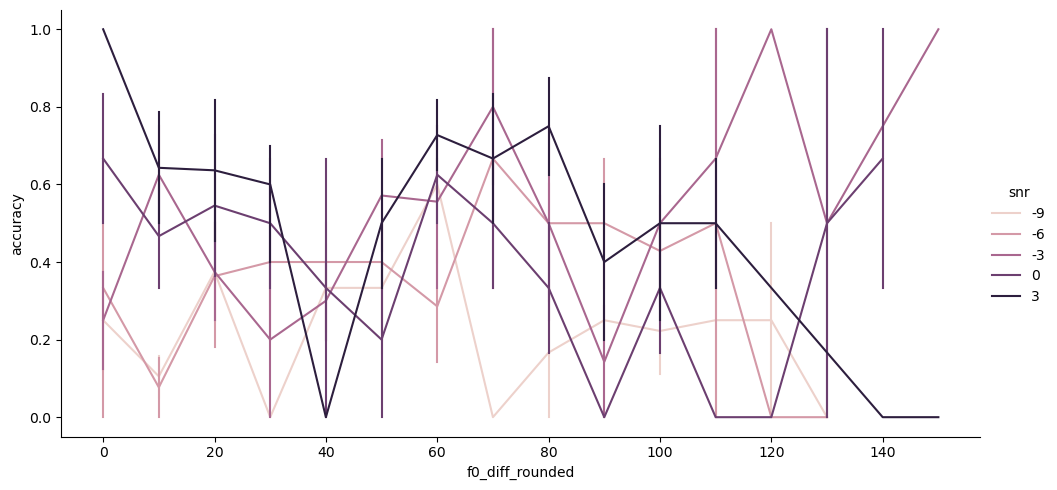

In [251]:
# g = sns.relplot(data=f0_analysis_df, x='f0_diff', y='snr', hue='accuracy',  kind='scatter')
# sns.violinplot(data=f0_analysis_df, x="snr", y="f0_diff", hue="accuracy", split=True, gap=.5, inner="quart")

to_plot = f0_analysis_df[(f0_analysis_df.condition == '1-talker')] 
to_plot["f0_diff_rounded"] = to_plot.f0_diff.round(-1)
ax = sns.relplot(data=to_plot, x="f0_diff_rounded", y="accuracy", hue='snr', kind='line', aspect=2, err_style="bars", ci=68, estimator='mean')
# sns.move_legend(ax, title='', 
#                 loc="center right", bbox_to_anchor=(1.5, .7),
#                 frameon=False, )
# sns.despine()
# sns.despine()
# ax.set_ylabel('f0 difference (Hz)', fontsize=fontsize)
# ax.set_xlabel('dB SNR', fontsize=fontsize)

In [252]:
# get trial data excluding catch trials 
gender_cond_analysis_df = f0_analysis_df[(~f0_analysis_df.condition.isnull()) & (~f0_analysis_df.response_str.isna())]


gender_cond_analysis_df = (gender_cond_analysis_df.groupby(["snr", 'id_subject', "gender_cond"])
                     .agg({"correct":"mean", "confusions": "mean"})
                     .reset_index())

gender_cond_analysis_df['snr'] = gender_cond_analysis_df['snr'].replace(np.inf, 6)
gender_cond_analysis_df['snr'] =  gender_cond_analysis_df['snr'].replace("inf", 6)
gender_cond_analysis_df['snr'] = gender_cond_analysis_df['snr'].astype('int')


In [253]:
gender_cond_analysis_df.loc[gender_cond_analysis_df.snr == 6, "gender_cond"] = "clean"

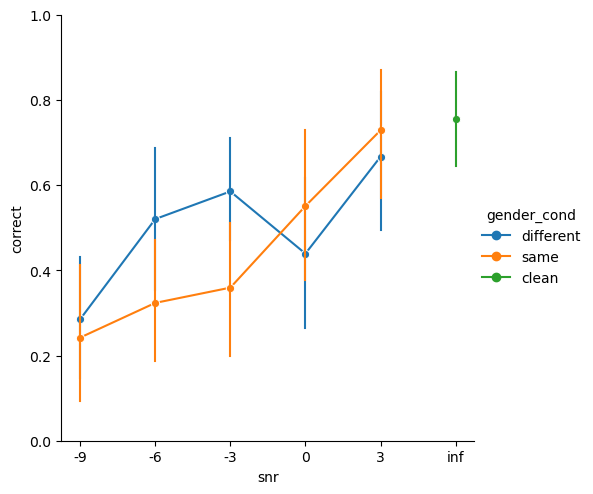

In [254]:
g = sns.relplot(data=gender_cond_analysis_df, x='snr', y='correct', hue='gender_cond', kind='line', err_style = 'bars',style="gender_cond", markers=["o", "o", "o"], dashes=False)
x_tick_locs = gender_cond_analysis_df.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
# labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
    plt.ylim(0,1)


(0.0, 1.0)

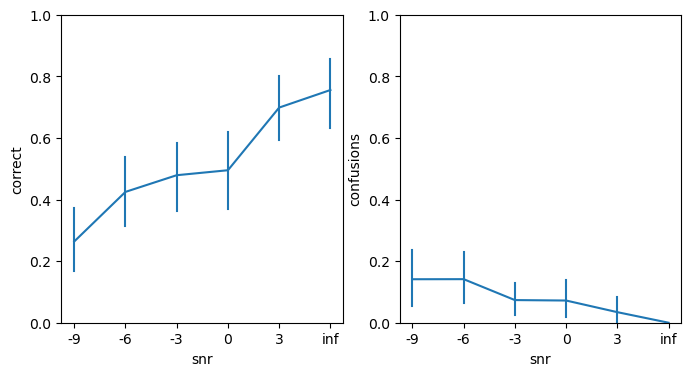

In [255]:
fig, axs = plt.subplots(1,2, figsize=(8,4))

g = sns.lineplot(data=gender_cond_analysis_df, x = 'snr', y = 'correct', err_style='bars', 
            ax=axs[0])

g1 = sns.lineplot(data=gender_cond_analysis_df, x = 'snr', y = 'confusions',  err_style='bars',  
            ax=axs[1])

g.set_xticks(ticks=x_tick_locs) # set new labels
g1.set_xticks(ticks=x_tick_locs) # set new labels
g.set_xticklabels(labels=x_tick_labels)
g1.set_xticklabels(labels=x_tick_labels)
g.set_ylim(0,1)
g1.set_ylim(0,1)



(0.0, 1.0)

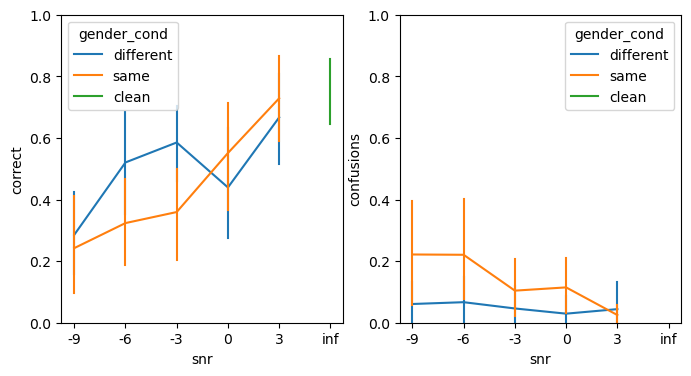

In [256]:
fig, axs = plt.subplots(1,2, figsize=(8,4))

g = sns.lineplot(data=gender_cond_analysis_df, x = 'snr', y = 'correct', err_style='bars', hue='gender_cond', 
            ax=axs[0])

g1 = sns.lineplot(data=gender_cond_analysis_df, x = 'snr', y = 'confusions',  err_style='bars',  hue='gender_cond',
            ax=axs[1])

g.set_xticks(ticks=x_tick_locs) # set new labels
g1.set_xticks(ticks=x_tick_locs) # set new labels
g.set_xticklabels(labels=x_tick_labels)
g1.set_xticklabels(labels=x_tick_labels)
g.set_ylim(0,1)
g1.set_ylim(0,1)

